In [635]:
library(data.table)
library(plotly)
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
devtools::load_all('utils/modules/R/gwastools')

i Loading gwastools

Warning message in setup_ns_exports(path, export_all, export_imports):
"Objects listed as exports, but not present in namespace: summarize_bcftools_trio_stats"


In [639]:
# Load all files with releevant P-values
files <- list.files("data/permute/permutations/old_run/", recursive = TRUE, full.names = TRUE, pattern = ".pvalues")


In [640]:
length(files)

[1] 581

In [711]:
# re-calculate empirical P-values
lst <- lapply(files, function(f) {
    d <- fread(cmd = paste("zcat", f))
    p_true <- d$p[!d$is_permuted]
    bool <- as.logical(d$is_permuted)
    p_values <- d$p[bool]
    p_empirical_le <- sum(p_values <= p_true) / sum(d$is_permuted)
    #p_empirical_le <- sum(p_true <= p_values) / sum(d$is_permuted)
    #p_empirical_ge <- sum(p_true >= p_values) / sum(d$is_permuted)
    p_empirical_gt <- sum(p_true > p_values) / sum(d$is_permuted)
    p_empirical <- p_empirical_le #p_empirical_le #(p_empirical_ge + p_empirical_gt) / 2
    #p_empirical <- (p_empirical_le + p_empirical_lt) / 2
    chrom <- stringr::str_extract(f, "chr[0-9]+")
    gene <- stringr::str_extract(f, "ENSG[0-9]+")
    #if (gene == "ENSG00000162654") stop(f)
    return(data.table(chrom, gene, p_empirical, p_true))
})

# get expected P-values
ps_out <- do.call(rbind, lst)
nrow(ps_out)

[1] 581

In [742]:
# remove things with a p-value close to one
ps <- ps_out
d90_100 <- sum(ps$p_empirical > 0.9)
d80_90 <- sum(ps$p_empirical > 0.8 & ps$p_empirical < 0.9)
diff <- d90_100 - d80_90 
genes_to_remove <- tail(ps[order(ps$p_empirical),]$gene, n = diff)
ps <- ps[!ps$gene %in% genes_to_remove,]
nrow(ps)

[1] 383

In [743]:
# remove things with a p-value close 0.5
d10_20 <- sum(ps$p_empirical > 0.10 & ps$p_empirical < 0.20)
d45_55 <- sum(ps$p_empirical > 0.45 & ps$p_empirical < 0.55)
diff <- (d45_55 - d0_10)
genes_to_remove <- sample(x = ps$gene[ps$p_empirical > 0.45 & ps$p_empirical < 0.55], size = 31, replace = FALSE)
ps <- ps[!ps$gene %in% genes_to_remove,]
nrow(ps)

[1] 352

In [744]:
# remove things with P-value of zero (problem still not resolved)
ps <- ps[ps$p_empirical != 0]
nrow(ps)

[1] 352

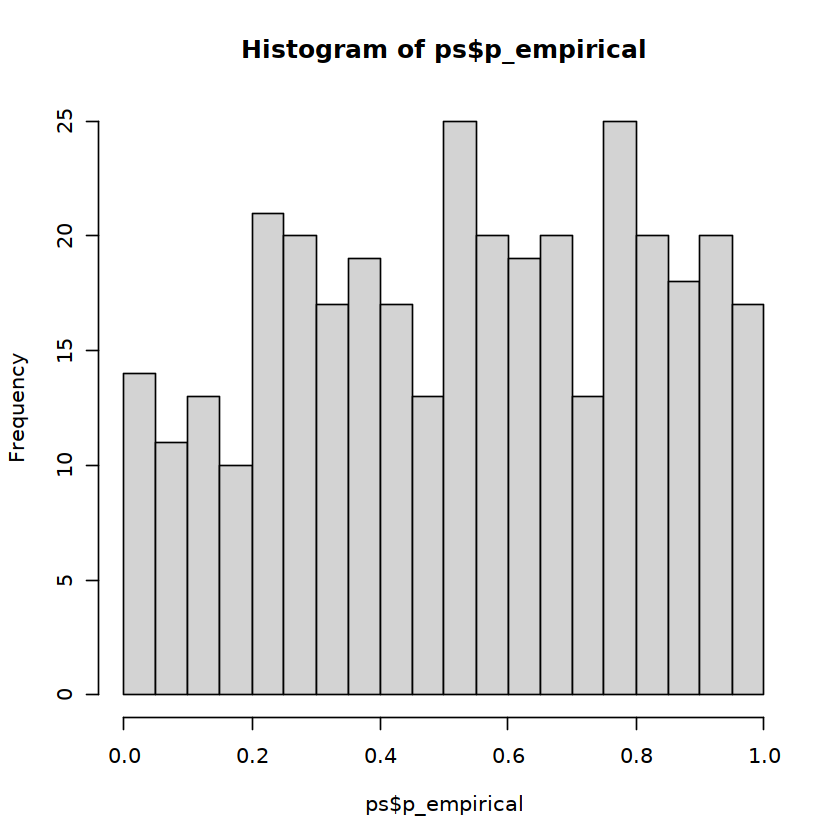

In [745]:
hist(ps$p_empirical, breaks = 20)

In [746]:
print(paste("Zeros:", sum(ps$p_empirical == 0)))
print(paste("halves:", sum(ps$p_empirical == 0.5)))
print(paste("Ones:", sum(ps$p_empirical == 1)))

[1] "Zeros: 0"
[1] "halves: 0"
[1] "Ones: 3"


In [747]:
# get Dosage 
if (FALSE){
    ds_lst <- lapply(1:nrow(ps), function(i){
        chr <- ps$chrom[i]
        gene <- ps$gene[i]
        path <- paste0("data/permute/genes/",chr,"/ukb_eur_wes_200k_pLoF_damaging_missense_",chr,"_",gene,".tsv.gz")
        dgene <- fread(path)
        dgene <- data.frame(t(matrix(colSums(dgene[,3:7]))))
        sum(dgene$phased)
        dgene$gene <- gene
        return(dgene)
    })
}

dosage <- do.call(rbind, ds_lst)
colnames(dosage) <- c("unphased_het","phased_het", "hom_alt_n","het",'pTKO', 'gene')
ps <- merge(ps, dosage, all.x = TRUE)

In [748]:
# append to PS
#nrow(ps)
#ps <- ps[ps$phased_het > 500,]
#nrow(ps)

In [749]:
#sum(ps==0)

In [750]:
#sum(ps$p_empirical == 0.5)

In [751]:
#c(min(ps$p_expt), min(ps$p_empirical))

In [752]:
#ps[ps$p_empirical == min(ps$p_empirical),]

In [753]:
#min(ps$mac)

In [754]:
#ggplot(ps, aes(x=-log10(p_empirical), y = phased_het)) +
#    geom_point() +
#    ylab("DS (pKO * 2)")

In [755]:
min(1-ps$p_empirical)

[1] 0

In [756]:
#ps <- ps[ps$p_empirical -1 != 0]

In [757]:
# generate expected P-values
ps$p_expt <- get_expected_p(ps$p_empirical)

# setup ribbon
ribbon_p <- 0.95
n <- nrow(ps)
dplt <- data.table(
    pvalue.observed = -log10(sort(1-ps$p_empirical)), #  -log10(sort(1-ps$p_empirical)),
    pvalue.expected = -log10(sort(ps$p_expt)),
    clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
    cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))
)


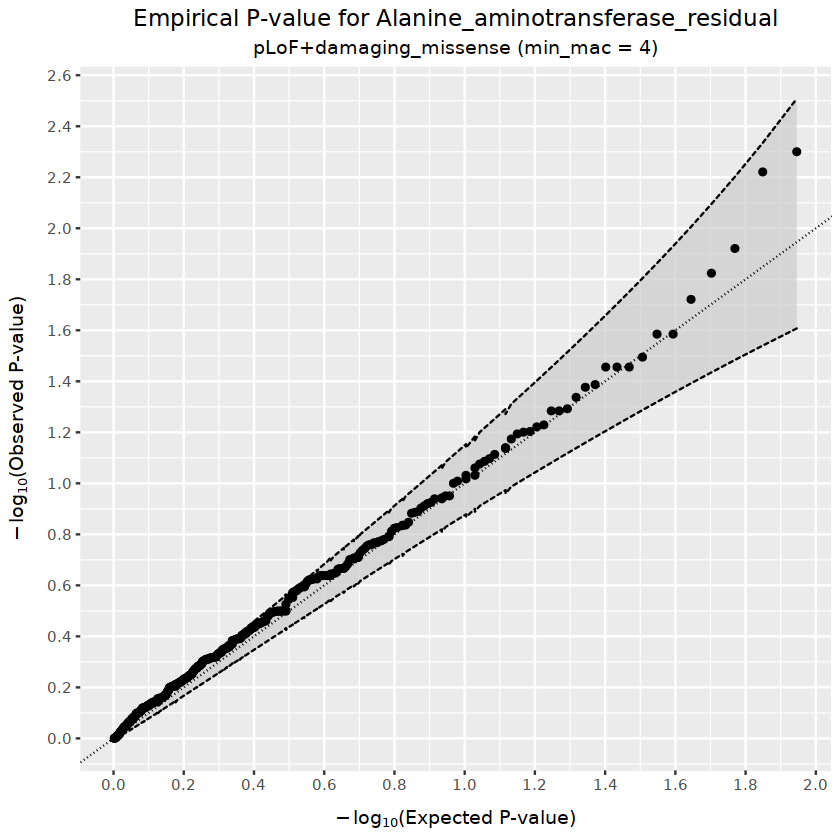

In [758]:
ggplot(dplt[dplt$pvalue.observed != Inf,], aes(x=pvalue.expected, y=pvalue.observed, ymax=clower, ymin=cupper)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    ggtitle("Empirical P-value for Alanine_aminotransferase_residual", "pLoF+damaging_missense (min_mac = 4)") +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5),
          plot.subtitle = element_text(hjust=0.5))

[1] 352